<a href="https://colab.research.google.com/github/AnnaZapototska/colab-code-work/blob/development/homework_2_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1. Music service analytics


## Аналіз множин: музичні слухачі

Дано три множини користувачів:

$$
A = \{101, 102, 103, 105, 107, 109, 110, 112, 115, 118\}, \quad
B = \{102, 104, 105, 106, 108, 110, 111, 113, 115, 117\}, \quad
C = \{103, 105, 108, 110, 112, 114, 115, 116, 119, 120\}
$$

---

### 1. Загальне охоплення (хоча б один жанр)

Використовуємо формулу включень та виключень:

$$
|A \cup B \cup C| = |A| + |B| + |C| - |A \cap B| - |A \cap C| - |B \cap C| + |A \cap B \cap C|
$$

Підставляємо значення:

$$
|A \cup B \cup C| = 10 + 10 + 10 - 4 - 5 - 4 + 3 = 20
$$

Отже, **унікальних слухачів** 20:

$$
A \cup B \cup C =
\{101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
111, 112, 113, 114, 115, 116, 117, 118, 119, 120\}
$$

---

### 2. Всеїдні меломани (слухали всі три жанри)

Перетин трьох множин:

$$
A \cap B \cap C = \{105, 110, 115\}, \quad |A \cap B \cap C| = 3
$$

---

### 3. Чисті рокери (тільки рок, без поп і джаз)

Виключаємо слухачів поп та джазу з рокерів:

$$
A - (B \cup C) = \{101, 107, 109, 118\}, \quad |A - (B \cup C)| = 4
$$

---

### 4. Користувачі, які слухали рівно два жанри

Беремо попарні перетини та виключаємо тих, хто в усіх трьох:

$$
A \cap B = \{102, 105, 110, 115\} \rightarrow \{102\} \quad (\text{без } A \cap B \cap C)
$$

$$
A \cap C = \{103, 105, 110, 112, 115\} \rightarrow \{103, 112\}
$$

$$
B \cap C = \{105, 108, 110, 115\} \rightarrow \{108\}
$$

Об’єднуємо:

$$
\text{Exactly two genres} = \{102, 103, 108, 112\}, \quad |\text{Exactly two genres}| = 4
$$

---

### Підсумкова таблиця

| Категорія | Користувачі | Кількість |
|-----------|-------------|-----------|
| Всі 3 жанри | {105, 110, 115} | 3 |
| Тільки рок | {101, 107, 109, 118} | 4 |
| Рівно 2 жанри | {102, 103, 108, 112} | 4 |

Unique listeners: {101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120}
Count: 20

All-genre listeners: {105, 115, 110}
Count: 3

Pure rock fans: {109, 107, 101, 118}
Count: 4

Users with exactly two genres: {112, 108, 102, 103}
Count: 4


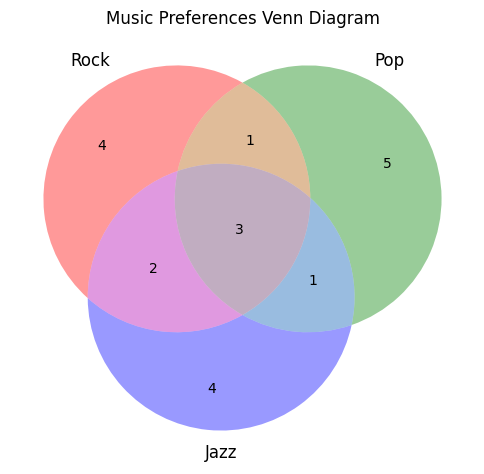

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# All listeners
rock_fans = {101, 102, 103, 105, 107, 109, 110, 112, 115, 118}

pop_fans = {102, 104, 105, 106, 108, 110, 111, 113, 115, 117}

jazz_fans = {103, 105, 108, 110, 112, 114, 115, 116, 119, 120}

# 1. All-genre listeners
l_rock_fans = len(rock_fans)
l_pop_fans = len(pop_fans)
l_jazz_fans = len(jazz_fans)

unique_listeners = rock_fans | pop_fans | jazz_fans
print("Unique listeners:", unique_listeners)
print("Count:", len(unique_listeners))

# 2. music lovers
music_lovers = rock_fans & pop_fans & jazz_fans
print("\nAll-genre listeners:", music_lovers)
print("Count:", len(music_lovers))

# 3. rockers
rockers = rock_fans - pop_fans - jazz_fans
print("\nPure rock fans:", rockers)
print("Count:", len(rockers))

# 4. Users who listened to exactly TWO genres

rock_pop = rock_fans & pop_fans
rock_jazz = rock_fans & jazz_fans
pop_jazz = pop_fans & jazz_fans

all_three = rock_fans & pop_fans & jazz_fans

exactly_two = (rock_pop | rock_jazz | pop_jazz) - all_three

print("\nUsers with exactly two genres:", exactly_two)
print("Count:", len(exactly_two))

# Venn diagram visualization
plt.figure(figsize=(6,6))
venn3([rock_fans, pop_fans, jazz_fans], ('Rock', 'Pop', 'Jazz'))
plt.title("Music Preferences Venn Diagram")
plt.show()


# Task 2. System access configurator

## Аналіз доступів користувача

Дано булеві змінні:

$$
is\_employee,\ is\_verified,\ is\_premium,\ is\_admin,\ is\_banned
$$

---

### 1. Логічні правила доступу

$$
\text{Base} = is\_employee \land is\_verified \land \neg is\_banned
$$

$$
\text{Premium} = (is\_employee \lor is\_premium) \land is\_verified \land \neg is\_banned
$$

$$
\text{Admin} = is\_admin \land is\_verified \land \neg is\_banned
$$

$$
\text{Secret} = (is\_admin \lor (is\_employee \land is\_premium)) \land is\_verified \land \neg is\_banned
$$

---

### 2. Таблиця істинності

Кількість всіх можливих комбінацій:

$$
2^5 = 32
$$

Перебираємо всі значення змінних та обчислюємо доступи.

---

### 3. Повний доступ (всі 4 рівні)

Потрібно:

$$
\text{Base} = \text{Premium} = \text{Admin} = \text{Secret} = 1
$$

Це можливо лише коли:

$$
is\_employee = 1,\quad is\_verified = 1,\quad is\_admin = 1,\quad is\_banned = 0
$$

Змінна \( is\_premium \) може бути будь-якою:

$$
is\_premium = 0 \text{ або } 1
$$

Отже:

$$
\text{Кількість випадків} = 2
$$

---

### 4. Випадок: Premium = 1, але Base = 0

Умова:

$$
\text{Premium} = 1,\quad \text{Base} = 0
$$

Приклад:

$$
(0,\ 1,\ 1,\ 0,\ 0)
$$

Перевірка:

$$
\text{Base} = 0 \land 1 \land 1 = 0
$$

$$
\text{Premium} = (0 \lor 1) \land 1 \land 1 = 1
$$

---

### Висновок

- Повний доступ: **2 випадки**
- Premium без Base: **існує**
- Причина: використання операції \( OR \) у Premium

---

### Підсумкова таблиця

| Умова | Результат |
|------|----------|
| Повний доступ (усі 4 = 1) | 2 |
| Premium = 1, Base = 0 | існує |

In [ ]:
from itertools import product
from prettytable import PrettyTable

# RBAC — Role-Based Access Control
# 1
def check_access(is_employee, is_verified, is_premium, is_admin, is_banned):
    # Base access: employee AND verified AND not banned
    access_base = is_employee and is_verified and not is_banned

    # Premium access: (employee OR premium) AND verified AND not banned
    access_premium = (is_employee or is_premium) and is_verified and not is_banned

    # Admin access: admin AND verified AND not banned
    access_admin = is_admin and is_verified and not is_banned

    # Secret access:
    # (admin OR (employee AND premium)) AND verified AND not banned
    access_secret = (is_admin or (is_employee and is_premium)) and is_verified and not is_banned

    # Return results as a dictionary
    return {
        'Base': access_base,
        'Premium': access_premium,
        'Admin': access_admin,
        'Secret': access_secret
    }


# 2 / 3
# using prettytable tools to make it as a table
table = PrettyTable()
table.field_names = ['emp', 'ver', 'prem', 'adm', 'ban', 'Base', 'Premium', 'Admin', 'Secret']

for values in product([False, True], repeat=5):
    res = check_access(*values)

    row = list(map(int, values)) + [
        int(res['Base']),
        int(res['Premium']),
        int(res['Admin']),
        int(res['Secret'])
    ]

    table.add_row(row)

print(table)

# 4
# In how many cases does a user have full access (to all 4 sections simultaneously)?
full_access_count = 0

for values in product([False, True], repeat=5):
    res = check_access(*values)

    # Check if ALL access levels are True
    if all(res.values()):
        full_access_count += 1

print("\nFull access count:", full_access_count)

# Is there a combination where the user has access to Premium but does not have access to Base?
# If so, output the parameters of this combination and explain why this is the case.

premium_access_combination = False

for values in product([False, True], repeat=5):
    is_employee, is_verified, is_premium, is_admin, is_banned = values
    res = check_access(*values)

    if res['Premium'] and not res['Base']:
        print("\nFound combination:")
        print(dict(zip(['emp','ver','prem','adm','ban'], values)))
        print("\nResult:", res)
        premium_access_combination = True
        break

if not premium_access_combination:
    print("No such combination exists")

# Response:
# Base = is_employee AND is_verified AND NOT is_banned
# Premium = (is_employee OR is_premium) AND is_verified AND NOT is_banned
# Reason → OR in Premium instead of AND



+-----+-----+------+-----+-----+------+---------+-------+--------+
| emp | ver | prem | adm | ban | Base | Premium | Admin | Secret |
+-----+-----+------+-----+-----+------+---------+-------+--------+
|  0  |  0  |  0   |  0  |  0  |  0   |    0    |   0   |   0    |
|  0  |  0  |  0   |  0  |  1  |  0   |    0    |   0   |   0    |
|  0  |  0  |  0   |  1  |  0  |  0   |    0    |   0   |   0    |
|  0  |  0  |  0   |  1  |  1  |  0   |    0    |   0   |   0    |
|  0  |  0  |  1   |  0  |  0  |  0   |    0    |   0   |   0    |
|  0  |  0  |  1   |  0  |  1  |  0   |    0    |   0   |   0    |
|  0  |  0  |  1   |  1  |  0  |  0   |    0    |   0   |   0    |
|  0  |  0  |  1   |  1  |  1  |  0   |    0    |   0   |   0    |
|  0  |  1  |  0   |  0  |  0  |  0   |    0    |   0   |   0    |
|  0  |  1  |  0   |  0  |  1  |  0   |    0    |   0   |   0    |
|  0  |  1  |  0   |  1  |  0  |  0   |    0    |   1   |   1    |
|  0  |  1  |  0   |  1  |  1  |  0   |    0    |   0   |   0 

# Task 3. Forming a "Dream Team"

## Формування команди стартапу

Дано:

- Back-end розробники: \(8\)
- Front-end розробники: \(6\)
- Дизайнери: \(4\)

Команда повинна складатися з:

- \(2\) Back-end
- \(2\) Front-end
- \(1\) Designer

---

### 1. Вибір Back-end розробників

$$
C(8,2) = \frac{8!}{2!(8-2)!} = \frac{8 \cdot 7}{2} = 28
$$

---

### 2. Вибір Front-end розробників

$$
C(6,2) = \frac{6!}{2!(6-2)!} = \frac{6 \cdot 5}{2} = 15
$$

---

### 3. Вибір дизайнера

$$
C(4,1) = \frac{4!}{1!(4-1)!} = 4
$$

---

### 4. Загальна кількість команд

Використовуємо правило множення:

$$
\text{Total} = C(8,2) \cdot C(6,2) \cdot C(4,1)
$$

$$
= 28 \cdot 15 \cdot 4 = 1680
$$

---

### Висновок

$$
\text{Кількість можливих команд} = 1680
$$

In [ ]:
import math

# Number of ways to choose 2 back-end developers from 8
backend_choices = math.comb(8, 2)
print("\nBack-end combinations:", backend_choices)

# Number of ways to choose 2 front-end developers from 6
frontend_choices = math.comb(6, 2)
print("\nFront-end combinations:", frontend_choices)

# Number of ways to choose 1 front-end developers from 4
design_choices = math.comb(4, 1)
print("\nDesigner combinations:", design_choices)

# Total number of teams (multiplication rule)
total_teams = backend_choices * frontend_choices * design_choices

print("\nTotal possible teams:", total_teams)



Back-end combinations: 28
Front-end combinations: 15
Front-end combinations: 4

Total possible teams: 1680


# Task 4. Company social network analysis

## Аналіз графа співробітників

Дано неорієнтований граф контактів:

$$
V = \{\text{Анна, Богдан, Віктор, Ганна, Дмитро, Євген}\}
$$

---

### 1. Степінь вершин

Степінь вершини — це кількість її зв’язків:

$$
\deg(\text{Анна}) = 3
$$

$$
\deg(\text{Богдан}) = 3
$$

$$
\deg(\text{Віктор}) = 4
$$

$$
\deg(\text{Ганна}) = 3
$$

$$
\deg(\text{Дмитро}) = 3
$$

$$
\deg(\text{Євген}) = 2
$$

---

### 2. Найбільш і найменш комунікабельні

$$
\max \deg(v) = 4 \Rightarrow \text{Віктор}
$$

$$
\min \deg(v) = 2 \Rightarrow \text{Євген}
$$

---

### 3. Теорема про суму степенів

Формула:

$$
\sum \deg(v) = 2 \cdot |E|
$$

Обчислюємо суму степенів:

$$
3 + 3 + 4 + 3 + 3 + 2 = 18
$$

Кількість ребер:

$$
|E| = 9
$$

Перевірка:

$$
2 \cdot 9 = 18
$$

---

### Висновок

$$
\sum \deg(v) = 18 = 2 \cdot 9
$$

Теорема виконується.

Adjacency List:
Анна: ['Богдан', 'Віктор', 'Ганна']
Богдан: ['Анна', 'Віктор', 'Дмитро']
Віктор: ['Анна', 'Богдан', 'Ганна', 'Дмитро']
Ганна: ['Анна', 'Віктор', 'Євген']
Дмитро: ['Богдан', 'Віктор', 'Євген']
Євген: ['Ганна', 'Дмитро']

Adjacency Matrix:

              Анна  Богдан  Віктор   Ганна  Дмитро   Євген
Анна             0       1       1       1       0       0
Богдан           1       0       1       0       1       0
Віктор           1       1       0       1       1       0
Ганна            1       0       1       0       0       1
Дмитро           0       1       1       0       0       1
Євген            0       0       0       1       1       0

Edge List:
[('Анна', 'Богдан'), ('Анна', 'Віктор'), ('Анна', 'Ганна'), ('Богдан', 'Віктор'), ('Богдан', 'Дмитро'), ('Віктор', 'Ганна'), ('Віктор', 'Дмитро'), ('Ганна', 'Євген'), ('Дмитро', 'Євген')]

Degrees:
Анна: 3
Богдан: 3
Віктор: 4
Ганна: 3
Дмитро: 3
Євген: 2

Most communicative:
Віктор (4 connections)

Least communicative:


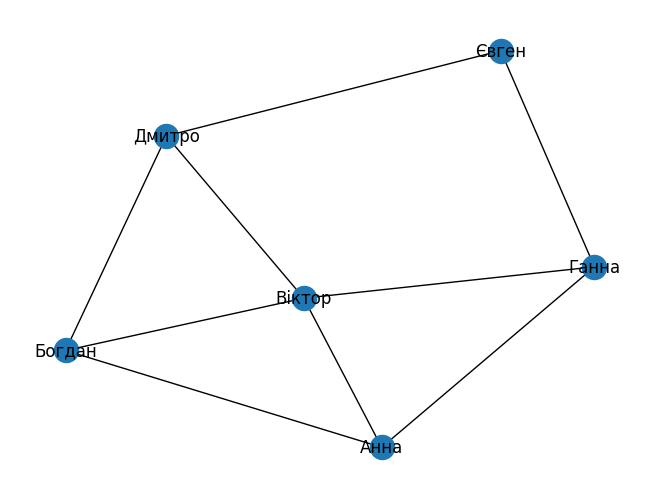

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# List
G = {
    "Анна": ["Богдан", "Віктор", "Ганна"],
    "Богдан": ["Анна", "Віктор", "Дмитро"],
    "Віктор": ["Анна", "Богдан", "Ганна", "Дмитро"],
    "Ганна": ["Анна", "Віктор", "Євген"],
    "Дмитро": ["Богдан", "Віктор", "Євген"],
    "Євген": ["Ганна", "Дмитро"]
}

adj_list = G
print("Adjacency List:")
for vertex, neighbors in adj_list.items():
    print(f"{vertex}: {neighbors}")

# Matrix
nodes = list(G.keys())
n = len(nodes)
adj_matrix = [[0]*n for _ in range(n)]

for i, node in enumerate(nodes):
    for neighbor in G[node]:
        j = nodes.index(neighbor)
        adj_matrix[i][j] = 1

print("\nAdjacency Matrix:\n")
print(" " * 10 + "".join(f"{name[:6]:>8}" for name in nodes))
for i, row in enumerate(adj_matrix):
    print(f"{nodes[i]:<10}" + "".join(f"{x:>8}" for x in row))

# Edges
edges = []

for node in G:
    for neighbor in G[node]:
        if (neighbor, node) not in edges:
            edges.append((node, neighbor))

print("\nEdge List:")
print(edges)

# Count degrees
degrees = {}

for node in G:
    degrees[node] = len(G[node])

print("\nDegrees:")
for node, deg in degrees.items():
    print(f"{node}: {deg}")

max_person = max(degrees, key=degrees.get)
max_degree = degrees[max_person]

min_person = min(degrees, key=degrees.get)
min_degree = degrees[min_person]

print("\nMost communicative:")
print(f"{max_person} ({max_degree} connections)")

print("\nLeast communicative:")
print(f"{min_person} ({min_degree} connections)")

# Sum of degrees
sum_degrees = sum(len(neighbors) for neighbors in G.values())

num_edges = sum_degrees // 2

# Check theorem
print("Sum of degrees:", sum_degrees)
print("Number of edges:", num_edges)
print("2 * edges:", 2 * num_edges)

if sum_degrees == 2 * num_edges:
    print("\n✅ The theorem holds: sum of degrees = 2 * edges")
else:
    print("\n❌ The theorem does NOT hold")



# Draw graph
G_nx = nx.Graph()

for node in G:
    for neighbor in G[node]:
        G_nx.add_edge(node, neighbor)

nx.draw(G_nx, with_labels=True)
plt.show()